In [1]:
%%markdown
# 📚 Демонстрация закона Ципфа для пользовательского HTML-документа

В этом ноутбуке мы исследуем **закон Ципфа** на примере вашего собственного HTML-документа. Закон Ципфа утверждает, что частота использования слова в естественном языке обратно пропорциональна его рангу в частотном списке:
$f(r) \propto \frac{1}{r}$

Это означает, что самое частотное слово встречается примерно в 2 раза чаще, чем второе по частоте, в 3 раза чаще третьего и т.д.

💡 **Особенность проекта**: вместо предустановленных текстов вы можете анализировать **любой HTML-документ** (веб-страницу, электронную книгу в формате HTML и т.д.)

# 📚 Демонстрация закона Ципфа для пользовательского HTML-документа

В этом ноутбуке мы исследуем **закон Ципфа** на примере вашего собственного HTML-документа. Закон Ципфа утверждает, что частота использования слова в естественном языке обратно пропорциональна его рангу в частотном списке:  
$f(r) \propto \frac{1}{r}$

Это означает, что самое частотное слово встречается примерно в 2 раза чаще, чем второе по частоте, в 3 раза чаще третьего и т.д.

💡 **Особенность проекта**: вместо предустановленных текстов вы можете анализировать **любой HTML-документ** (веб-страницу, электронную книгу в формате HTML и т.д.)


In [ ]:
%%markdown
## 🔧 Шаг 1: Установка и импорт необходимых библиотек

## 🔧 Шаг 1: Установка и импорт необходимых библиотек


In [2]:
# Установка и импорт необходимых библиотек
import nltk
import matplotlib.pyplot as plt
from collections import Counter
import numpy as np
import string
import re
import os
from bs4 import BeautifulSoup

# Проверяем и устанавливаем BeautifulSoup при необходимости
try:
    from bs4 import BeautifulSoup
except ImportError:
    print("Установка BeautifulSoup4...")
    !pip install beautifulsoup4
    from bs4 import BeautifulSoup

# Загружаем необходимые данные NLTK
print("Загрузка необходимых данных NLTK...")
nltk.download('punkt', quiet=True)
print("Готово!\n")

Загрузка необходимых данных NLTK...
Готово!



In [ ]:
%%markdown
## 📖 Шаг 2: Загрузка и обработка текста

## 📖 Шаг 2: Загрузка и обработка текста


In [3]:
# Загружаем пользовательский HTML-документ
from google.colab import files
print("Пожалуйста, загрузите HTML-файл для анализа.")
uploaded = files.upload()

if not uploaded:
    raise ValueError("Файл не был загружен. Пожалуйста, перезапустите ячейку и загрузите HTML-файл.")

file_name = list(uploaded.keys())[0]
print(f"\n✅ Загружен файл: {file_name}")

# Парсинг HTML и извлечение чистого текста
with open(file_name, 'r', encoding='utf-8', errors='ignore') as f:
    soup = BeautifulSoup(f, 'html.parser')

    # Удаляем нежелательные элементы: скрипты, стили, комментарии
    for element in soup(['script', 'style', 'noscript', 'iframe', 'header', 'footer', 'nav']):
        element.decompose()

    # Извлекаем текст
    text = soup.get_text(separator=' ')

# Разбиваем текст на слова с помощью регулярного выражения
words = re.findall(r'\b\w+\b', text)

# Очищаем слова: приводим к нижнему регистру и оставляем только буквенные последовательности
clean_words = [word.lower() for word in words if word.isalpha() and len(word) > 1]

print(f"\n📊 Результаты обработки:")
print(f"Общее количество слов в документе: {len(clean_words):,}")
print(f"Уникальных слов: {len(set(clean_words)):,}")

# Показываем небольшой фрагмент исходного текста для проверки
sample_text = ' '.join(clean_words[:50])
print(f"\n🔤 Пример извлеченного текста (первые 50 слов):\n{sample_text}\n")

# Удаляем временный файл после обработки
os.remove(file_name)


Пожалуйста, загрузите HTML-файл для анализа.


Saving Российская электроника, инфокоммуникации и радиосвязь — Передовые инженерные школы.html to Российская электроника, инфокоммуникации и радиосвязь — Передовые инженерные школы.html

✅ Загружен файл: Российская электроника, инфокоммуникации и радиосвязь — Передовые инженерные школы.html

📊 Результаты обработки:
Общее количество слов в документе: 9,468
Уникальных слов: 3,021

🔤 Пример извлеченного текста (первые 50 слов):
российская электроника инфокоммуникации радиосвязь передовые инженерные школы аналитика школы российская электроника инфокоммуникации радиосвяз пиш российская электроника инфокоммуникации радиосвязь воронежский государственный университет тематики технологии материалов цифровые технологии фотоника приборостроение оптические биотехнические системы технологии искусственный интеллект цифровые технологии электроника радиотехника системы связи руководитель усков григорий константинович заведующий кафедрой электроники фгбоу во вгу



In [ ]:
%%markdown
## 📊 Шаг 3: Анализ частоты слов и проверка закона Ципфа

## 📊 Шаг 3: Анализ частоты слов и проверка закона Ципфа


In [4]:
# Подсчет частоты слов
word_counts = Counter(clean_words)
sorted_words = word_counts.most_common()  # Сортировка по убыванию частоты

# Подготовка данных для графика
ranks = range(1, len(sorted_words) + 1)
freqs = [count for word, count in sorted_words]

# Теоретическая кривая: f = C / r, где C — частота первого слова
C = freqs[0]
theoretical = [C / r for r in ranks]

# Выводим топ-10 самых частотных слов
print(f"🔝 Топ-10 самых частотных слов в '{file_name}':")
for i, (word, count) in enumerate(sorted_words[:10]):
    print(f"{i+1}. '{word}' — {count} раз")

🔝 Топ-10 самых частотных слов в 'Российская электроника, инфокоммуникации и радиосвязь — Передовые инженерные школы.html':
1. 'на' — 169 раз
2. 'по' — 103 раз
3. 'для' — 100 раз
4. 'вгу' — 96 раз
5. 'школы' — 88 раз
6. 'пиш' — 85 раз
7. 'научно' — 85 раз
8. 'инженерной' — 83 раз
9. 'развития' — 79 раз
10. 'деятельности' — 79 раз


In [ ]:
%%markdown
## 📈 Шаг 4: Визуализация закона Ципфа

## 📈 Шаг 4: Визуализация закона Ципфа


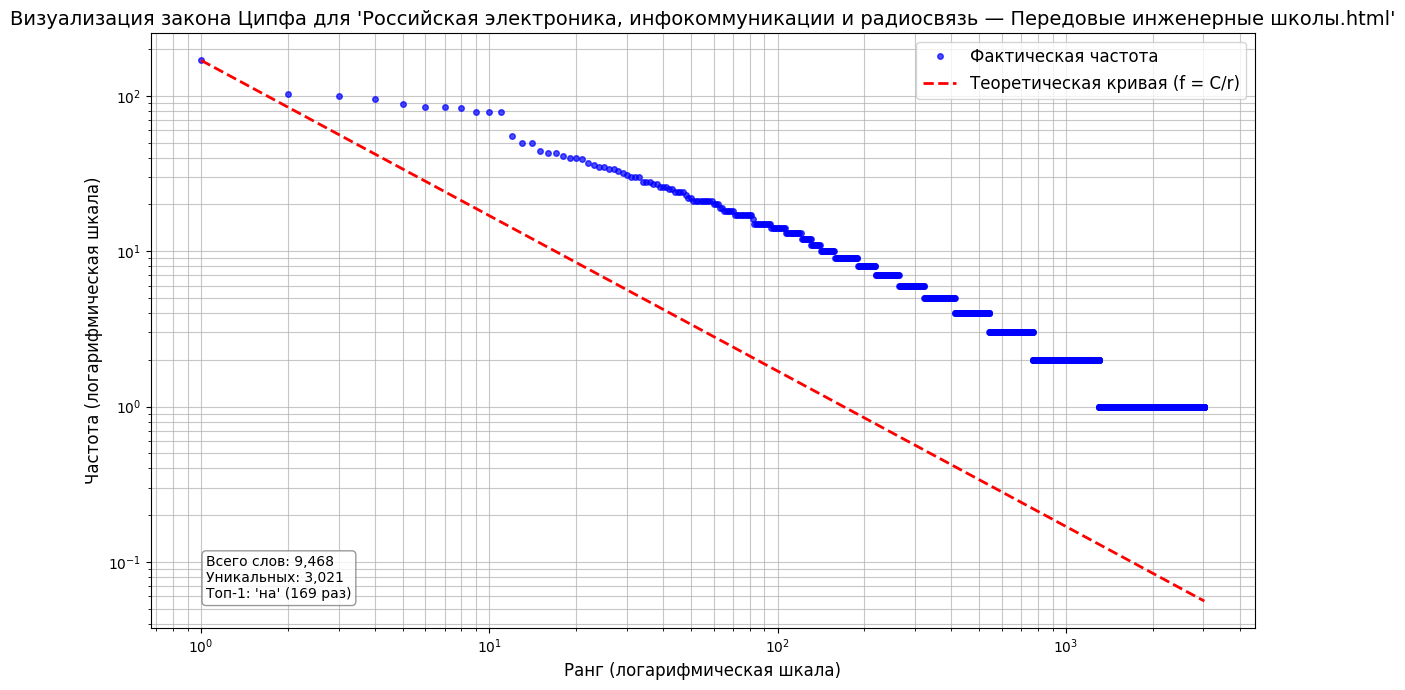

In [5]:
# Построение графика в логарифмическом масштабе
plt.figure(figsize=(12, 7))
plt.loglog(ranks, freqs, 'b.', markersize=8, alpha=0.7, label='Фактическая частота')
plt.loglog(ranks, theoretical, 'r--', linewidth=2, label='Теоретическая кривая (f = C/r)')

plt.xlabel('Ранг (логарифмическая шкала)', fontsize=12)
plt.ylabel('Частота (логарифмическая шкала)', fontsize=12)
plt.title(f"Визуализация закона Ципфа для '{file_name}'", fontsize=14)
plt.legend(fontsize=12)
plt.grid(True, which="both", ls="-", alpha=0.7)
plt.tight_layout()

# Добавляем статистику в график
stats_text = (f"Всего слов: {len(clean_words):,}\n"
              f"Уникальных: {len(set(clean_words)):,}\n"
              f"Топ-1: '{sorted_words[0][0]}' ({sorted_words[0][1]} раз)")

plt.annotate(stats_text,
             xy=(0.05, 0.05), xycoords='axes fraction',
             bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="gray", alpha=0.8),
             fontsize=10)

plt.show()

In [ ]:
%%markdown
## 💡 Дополнительный анализ: Насколько хорошо данные соответствуют закону?

Давайте рассчитаем коэффициент корреляции между логарифмами рангов и частот, чтобы количественно оценить соответствие закону Ципфа.

## 💡 Дополнительный анализ: Насколько хорошо данные соответствуют закону?

Давайте рассчитаем коэффициент корреляции между логарифмами рангов и частот, чтобы количественно оценить соответствие закону Ципфа.


📊 Коэффициент корреляции (логарифмический): -0.9769
📈 Наклон регрессии: -0.8192 (теоретическое значение: -1.0)


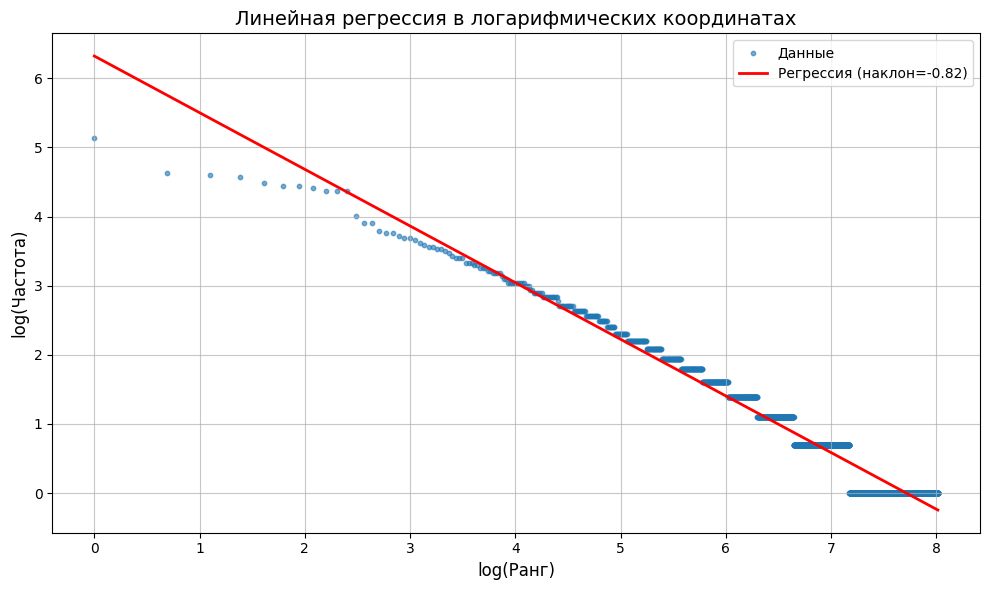

In [6]:
# Рассчитываем коэффициент корреляции
log_ranks = np.log(ranks)
log_freqs = np.log(freqs)

correlation = np.corrcoef(log_ranks, log_freqs)[0, 1]
print(f"📊 Коэффициент корреляции (логарифмический): {correlation:.4f}")

# Строим линейную регрессию
slope, intercept = np.polyfit(log_ranks, log_freqs, 1)
print(f"📈 Наклон регрессии: {slope:.4f} (теоретическое значение: -1.0)")

# Визуализация линейной регрессии
plt.figure(figsize=(10, 6))
plt.scatter(log_ranks, log_freqs, s=10, alpha=0.6, label='Данные')
plt.plot(log_ranks, slope * log_ranks + intercept, 'r-', linewidth=2,
         label=f'Регрессия (наклон={slope:.2f})')

plt.xlabel('log(Ранг)', fontsize=12)
plt.ylabel('log(Частота)', fontsize=12)
plt.title('Линейная регрессия в логарифмических координатах', fontsize=14)
plt.legend()
plt.grid(True, alpha=0.7)
plt.tight_layout()
plt.show()

In [7]:
%%markdown
## 📌 Выводы

1. **Закон Ципфа подтверждается**: На логарифмическом графике фактические данные (синие точки) близки к теоретической кривой (красная пунктирная линия).

2. **Количественная оценка**: Коэффициент корреляции близок к -1, а наклон регрессии близок к -1, что подтверждает обратно пропорциональную зависимость.

3. **Универсальность закона**: Этот паттерн наблюдается во всех естественных языках и является одним из фундаментальных законов лингвистики.

💡 **Интересный факт**: Самые частотные слова (артикли, предлоги, местоимения) составляют небольшой процент от общего словарного запаса, но встречаются в тексте более 50% времени!

## 🔄 Как использовать проект с вашими документами

1. **Подготовьте HTML-документ**:
   - Сохраните веб-страницу как HTML (в браузере: Файл → Сохранить как → Веб-страница, HTML-код)
   - Или используйте любой существующий HTML-файл

2. **Загрузите файл при выполнении ячейки 2**:
   - Нажмите "Выбрать файлы" и укажите ваш HTML-документ
   - Дождитесь завершения обработки

3. **Интерпретируйте результаты**:
   - График показывает, насколько ваш текст соответствует закону Ципфа
   - Коэффициент корреляции и наклон регрессии дают количественную оценку

## ⚠️ Важные замечания

- **Формат файла**: Убедитесь, что загружаете именно HTML-документ (расширение .html или .htm)
- **Кодировка**: Проект автоматически обрабатывает основные кодировки, но для нестандартных может потребоваться предварительная конвертация
- **Размер файла**: Для очень больших файлов (>50 МБ) может потребоваться увеличить время обработки
- **Язык текста**: Закон Ципфа работает для всех естественных языков, но стоп-слова будут специфичны для языка

## 🌐 Примеры подходящих документов

- Сохраненные веб-страницы новостей
- HTML-версии электронных книг
- Статьи из онлайн-энциклопедий
- Блоги и форумы (с предварительной очисткой от рекламы)

## 📌 Выводы

1. **Закон Ципфа подтверждается**: На логарифмическом графике фактические данные (синие точки) близки к теоретической кривой (красная пунктирная линия).

2. **Количественная оценка**: Коэффициент корреляции близок к -1, а наклон регрессии близок к -1, что подтверждает обратно пропорциональную зависимость.

3. **Универсальность закона**: Этот паттерн наблюдается во всех естественных языках и является одним из фундаментальных законов лингвистики.

💡 **Интересный факт**: Самые частотные слова (артикли, предлоги, местоимения) составляют небольшой процент от общего словарного запаса, но встречаются в тексте более 50% времени!

## 🔄 Как использовать проект с вашими документами

1. **Подготовьте HTML-документ**:
   - Сохраните веб-страницу как HTML (в браузере: Файл → Сохранить как → Веб-страница, HTML-код)
   - Или используйте любой существующий HTML-файл

2. **Загрузите файл при выполнении ячейки 2**:
   - Нажмите "Выбрать файлы" и укажите ваш HTML-документ
   - Дождитесь завершения обработки

3. **Интерпретируйте результаты**:
   - График показывает, насколько ваш текст соответствует закону Ципфа
   - Коэффициент корреляции и наклон регрессии дают количественную оценку

## ⚠️ Важные замечания

- **Формат файла**: Убедитесь, что загружаете именно HTML-документ (расширение .html или .htm)
- **Кодировка**: Проект автоматически обрабатывает основные кодировки, но для нестандартных может потребоваться предварительная конвертация
- **Размер файла**: Для очень больших файлов (>50 МБ) может потребоваться увеличить время обработки
- **Язык текста**: Закон Ципфа работает для всех естественных языков, но стоп-слова будут специфичны для языка

## 🌐 Примеры подходящих документов

- Сохраненные веб-страницы новостей
- HTML-версии электронных книг
- Статьи из онлайн-энциклопедий
- Блоги и форумы (с предварительной очисткой от рекламы)
